# Introduction
This is a tutorial for how to incorporate Xarray into your wrfout data analysis, much of the information is taken from the [Xarray documentation](https://docs.xarray.dev/en/stable/getting-started-guide/index.html).  

Xarray is a powerful Python package designed to build upon NumPy and Pandas, ingesting and interacting with multi-dimensional arrays.  

For example, WRF output variables are often multi-dimensional arrays encompassing time, latitude, longitude, height, and depth.  
Often, wrf simulations span multiple years split into only a few timesteps per out-file per day.  Xarray offers the ability to bulk open and organize your data with ease.


# Installation
Anaconda is recommended as the easiest way to install Xarray and the necessary dependencies.  
This tutorial uses python version 3.11.  
You can install the packages manually or use the Environment YAML file to install them for you.  
Using Anaconda Prompt create a new environment and install the core packages.

In [ ]:
conda create -n wrf-xarray python=3.11
conda activate wrf-xarray
conda install -c conda-forge xarray dask netcdf4 h5netcdf

* This installs:  
xarray → labeled array analysis  
dask → lazy parallel computation (for large datasets)
netcdf4 → NetCDF backend  
h5netcdf → alternate backend
## Additional Recommended Installations  
Below are additional commonly installed and recommeneded python packages related to using wrfout data.  
These all pair nicely with Xarray and are almost essential for geospatial data manipulation.
Using Anaconda Prompt:

In [ ]:
conda install -c conda-forge setuptools<81.0.0 wrf-python numpy pandas matplotlib cartopy

* This installs:  
wrf-python → wrfout handling  
setuptools → necessary for wrf-python and requires a version older than 82.0.0 as the "pkg_resource" sub-package is depreciated but required
numpy → numerical operations  
pandas → time handling  
matplotlib → plotting  
cartopy → maps/projections  

## Verify Installation
Recommend opening up python and importing the packages to ensure no errors arise.

In [2]:
import xarray as xr
import dask
import netCDF4
import wrf

print(xr.__version__)

c:\Users\cpjoh\anaconda3\envs\wrf-xarray\Lib\site-packages\wrf\__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026.4.0


## Alternate Installation
You can use the Evironment YAML (wrf-xarray-environment.yml) file to create the environment and install the necessary packages too.

In [ ]:
conda env create -f wrf-xarray-environment.yml
conda activate wrf-xarray

# Basic Information and Data Structures
Arrays found in files like wrfouts typically have "labels." These encode information about how the array values are mapped to geospatial coordinates, or time, or verticality.  If you just extract an array from wrfout using basic techniques, you extract none of the label information. You simply have an array of numbers. 

For example, 2-meter Temperature in wrfout has Time, south_north, and east_west dimensions.  A common way to retrieve 2-meter temperature for the first timestep would be "file["T2"][0,:,:]".  The variable returned would be a 2D array with no information regarding those dimension labels (Time, south_north, and east_west)

This can be perfectly fine, but when you need to extract a specific day or latitude/longitude range, it requires you to get creative in your approach to retrieve that data (usually through complicated indexing methods).  

Xarray data structures keep the array labels which allow you to more easily and concisely extract specific data, dates, regions, groupings and alignments.  Additionally, because the package uses labels, it means that you can more easily interpret your code.

## Data Structures
The two important datas strucutres are designed to bolster NumPy and Pandas arrays.
* DataArray: The labeled N-dimensional array.  For example, a specific variable like LAI, T2, or QCLOUD within a wrfout file.
* Dataset: The dictionary-like container of multiple DataArrays.  This is the wrfout file itself.  
So when you use Xarray to open a wrfout file, you are opening a Dataset and then can extract specific DataArrays by calling for the variables of interest.

# Opening and Viewing Datasets and DataArrays
Once installed and you've ensured that you can import the necessary packages, it's time to get started.  

The first step is practice opening and understanding the wrfout file.

## Opening A Single File
The basic function to open a file is [xarray.open_dataset](https://docs.xarray.dev/en/stable/generated/xarray.open_dataset.html). This function loads in a single file as the Dataset structure.  

This example uses a wrfout file that spans an 18-hour period from June 1, 2014 06 UTC to June 2, 2014 00 UTC.  The file contains four timesteps at 06 UTC, 12 UTC, 18 UTC, and 00 UTC.  It is a rectuangular domain extening across the equatorial Atlantic Ocean.

In [3]:
path = r"C:\Users\cpjoh\OneDrive\Desktop\work\PR_test_data\wrfout_d01_2014-06-01_06%3A00%3A00.nc"
ds = xr.open_dataset(path)
print(ds)
#Note that the Dataset provides the dimensions, coordinates, and all 253 wrfout variables.

<xarray.Dataset> Size: 533MB
Dimensions:                (Time: 4, south_north: 67, west_east: 251,
                            bottom_top: 39, bottom_top_stag: 40,
                            soil_layers_stag: 4, west_east_stag: 252,
                            south_north_stag: 68, dust_erosion_dimension: 3,
                            klevs_for_dust: 1, vprm_vgcls: 8)
Coordinates:
    XTIME                  (Time) datetime64[ns] 32B ...
    XLAT                   (Time, south_north, west_east) float32 269kB ...
    XLONG                  (Time, south_north, west_east) float32 269kB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 273kB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 273kB ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 270kB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 270kB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
       

## Viewing DataArrays and Metadata
The entire wrfout file is open, but often, the variable DataArrays within are more important.  These are easily callable through labelling.  

The basic format to call one of the Dataset's individual DataArrays is by "dataset_name.DataArray_name".

Each wrfout variable's label is the variable name.  For example, "LU_INDEX" (land-use index) is the variable name in the wrfout and, subsequently, label.  

2-Meter Temperature's callable variable name and label in wrfout files is "T2".

In [4]:
t2 = ds.T2 #2-meter temperature
print(t2)
#Note T2's three dimensions and dimension index lengths (Time, south_north, west_east)
#As well as the coordinates each dimension uses (XTIME, XLAT, XLONG)

<xarray.DataArray 'T2' (Time: 4, south_north: 67, west_east: 251)> Size: 269kB
[67268 values with dtype=float32]
Coordinates:
    XTIME    (Time) datetime64[ns] 32B ...
    XLAT     (Time, south_north, west_east) float32 269kB ...
    XLONG    (Time, south_north, west_east) float32 269kB ...
Dimensions without coordinates: Time, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger:      


It's important to notice that the time coordinate is XTIME, which is not a human readable format but is usually in "minutes since simulation start time."  

This poses a clear utility problem in situations where specific days/times are needed, but the solution will come later.  For now, its time to learn how to slice and examine specific sections of a DataArray.

There are two ways of calling a variable DataArray.  The above method which includes the variable label, but the other method uses a dictionary style calling, which can be more explicit depending on the variable name.

In [4]:
t2 = ds["T2"] #Same as above, but using dictionary-style indexing instead of attribute-style indexing
print(t2)

<xarray.DataArray 'T2' (Time: 4, south_north: 67, west_east: 251)> Size: 269kB
[67268 values with dtype=float32]
Coordinates:
    XTIME    (Time) datetime64[ns] 32B ...
    XLAT     (Time, south_north, west_east) float32 269kB ...
    XLONG    (Time, south_north, west_east) float32 269kB ...
Dimensions without coordinates: Time, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger:      


## Examining Data Array Values
Now, 2-meter temperature is in the form of an xarray.DataArray.  The metadata is readily apparent; dimensions and coordinates, but sometimes just seeing the raw values can help put the data into perspective.  Using the .values label turns the output into a NumPy array.  This drops much of the xarray utilities, but the simplicity can be convenient.

In [7]:
print(t2.values) #The actual data values of T2 as a numpy array
t2_numpy = t2.values
print(type(t2_numpy)) #Confirming that it's a numpy array
print(t2_numpy.shape) #Shape of the numpy array (Time, south_north, west_east)

[[[299.39932 299.5241  299.6534  ... 302.07297 300.8289  300.28183]
  [299.92752 299.76163 299.85812 ... 301.92413 300.63516 299.90103]
  [300.02917 299.93994 299.93747 ... 300.85443 300.1861  300.06152]
  ...
  [293.24963 292.66272 292.57397 ... 304.353   302.7705  302.77216]
  [293.89795 293.36893 293.04462 ... 302.297   301.86795 301.56232]
  [294.38083 294.07944 293.51776 ... 301.95718 301.28967 300.52545]]

 [[299.15723 299.29492 299.4819  ... 301.07776 300.51392 300.24905]
  [299.36377 299.4332  299.64774 ... 301.73575 301.28314 301.1205 ]
  [299.90695 299.7636  299.78293 ... 301.29913 301.12613 301.05066]
  ...
  [294.56937 293.687   293.46448 ... 305.8712  305.4453  306.34995]
  [294.81216 294.2438  294.0013  ... 304.36072 303.68173 304.83685]
  [295.35373 294.9874  294.76654 ... 305.65234 304.7185  304.7021 ]]

 [[299.5146  299.70596 299.88965 ... 299.9243  300.34216 300.4057 ]
  [299.7747  299.822   299.98373 ... 300.2991  300.119   300.4998 ]
  [300.07297 300.06024 300.23337


## Index-Selecting and Slicing

There are many possible ways to select subsets of a DataArray.  Identical to NumPy array selection, the indexes can be used directly.

In [ ]:
t2_subset = t2[0,:,2:5] #Select the first time step of T2
print(t2_subset)

<xarray.DataArray 'T2' (south_north: 67, west_east: 3)> Size: 804B
[201 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 804B ...
    XLONG    (south_north, west_east) float32 804B ...
    XTIME    datetime64[ns] 8B ...
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger:      


An alterate method uses the [.isel](https://docs.xarray.dev/en/latest/generated/xarray.Dataset.isel.html) function and slice.  This function allows you to select dimensions by indexes.  For WRF purposes, either work, but lets you more explicitly identify what dimensions are being extracted.  

The slice(...), lets you get the values within an index range.

In [ ]:
t2_subset = t2.isel(Time=0, south_north=slice(2, 5)) #Same as above, but using xarray's isel method for indexing
print(t2_subset)

<xarray.DataArray 'T2' (south_north: 3, west_east: 251)> Size: 3kB
[753 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 3kB ...
    XLONG    (south_north, west_east) float32 3kB ...
    XTIME    datetime64[ns] 8B ...
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger:      


Xarray also contains a few built in [plotting](https://docs.xarray.dev/en/latest/generated/xarray.DataArray.plot.html) functions.  

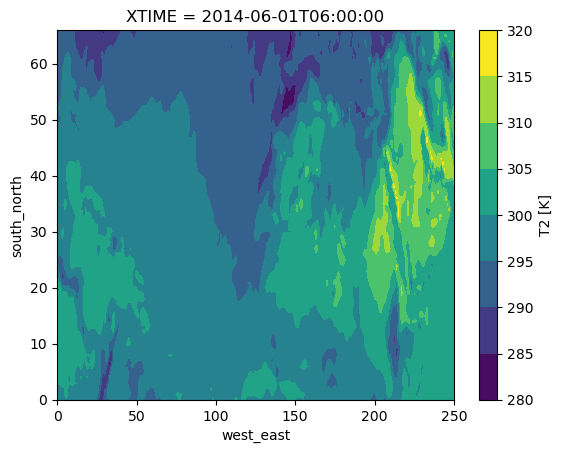

In [ ]:
import matplotlib.pyplot as plt
t2[0].plot.contourf() #Plot the first time step of T2 using xarray's built-in plotting functionality
plt.show()

Arguments and typical matplotlib and cartopy features work easily as well.

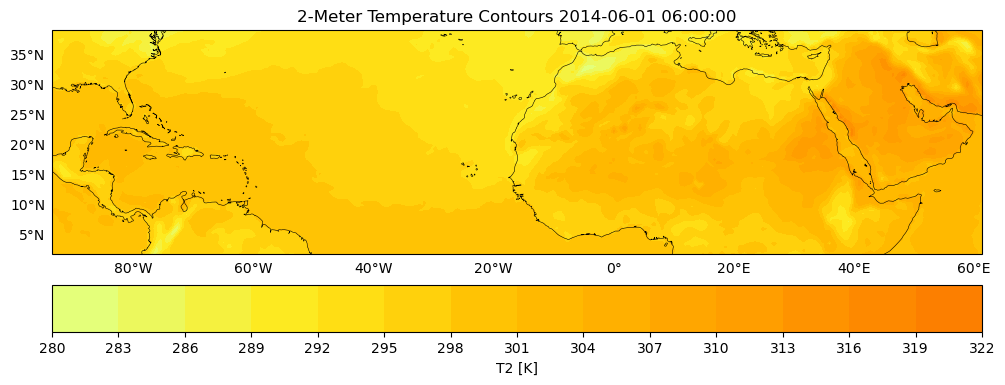

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

contour_range = np.arange(280, 325, 3) #Define contour levels from 280 to 324 with a step of 3.  Used in the contourf method below to specify which contour levels to plot.

fig = plt.figure(figsize=(12,8))             #Create a figure with a specific size.  Conceptually, this is the Frame of a painting
ax = plt.axes(projection=ccrs.PlateCarree()) #This creates an Axes object with a specific map projection.  Conceptually, this is the Canvas of a painting, where the actual plot will be drawn.  The projection determines how the data will be transformed to fit on the canvas.

#Below is the actual plotting code; the painting, using Xarray's built-in plotting functionality, which is based on Matplotlib.  The contourf method creates a filled contour plot of the first time step of T2.
t2[0,:,:].plot.contourf(ax=ax,x="XLONG",y="XLAT",  #specifies which axis to plot upon, and which coordinates to use for the x and y axes
                        levels=contour_range,      #specifies which contour levels to plot, using the contour_range array defined above
                        cmap='Wistia',             #the colormap to use
                        cbar_kwargs={'orientation': 'horizontal', 
                                     'ticks': contour_range, 
                                     'pad': 0.05} #Using Dictionary unpacking to specify colorbar keyword arguments.  dictates 'horizontal' and 'vertical', 'ticks' which match the contour_range, and 'pad' for better visualization.
                        ) 

ax.add_feature(cfeature.COASTLINE,linewidth=0.4) #adds coastlines to the plot for better visualization, with a specified line width

plt.title("2-Meter Temperature Contours " + 
          str(t2.XTIME[0].values).split("T")[0] +
          " " +
          str(t2.XTIME[0].values).split("T")[1].split(".")[0]
            ) #Extracting just the date from the XTIME coordinate for the plot title (Normally looks like "2014-06-01T06:00:00.000000000")

g1 = ax.gridlines(draw_labels=True,linewidth=0.5,linestyle='--', alpha=0) #Adds gridlines to the plot, with specified line width, line style, and transparency (alpha).  draw_labels=True adds labels to the gridlines, which are then customized in the next lines of code.
g1.top_labels=    False
g1.right_labels=  False
g1.bottom_labels= True
g1.left_labels=   True

plt.show()

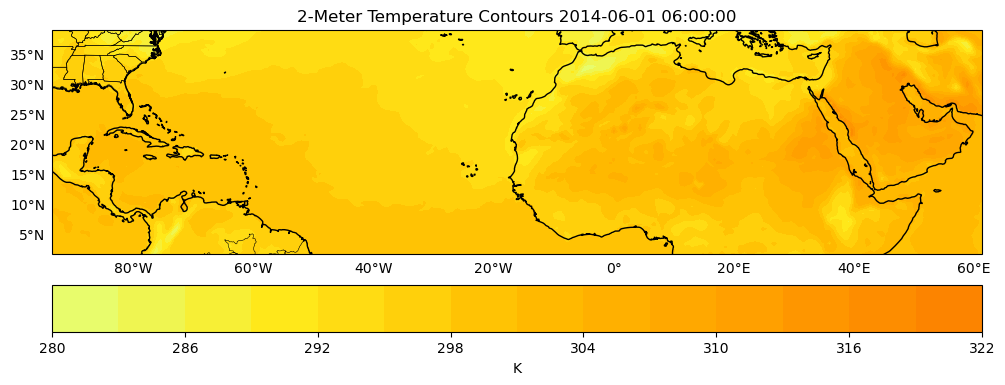

<Figure size 640x480 with 0 Axes>

In [15]:
from wrf_precip_plotting_functions import plotting
plotted = t2[0,:,:]
plotting(plotted=plotted,
         lons=t2.XLONG[0,:,:],
         lats=t2.XLAT[0,:,:],
         contour_range=[280,325,3],
         cmap='Wistia',
         cbar_extent="neither",
         cbar_label=t2.units,
         title="2-Meter Temperature Contours " + str(t2.XTIME[0].values).split("T")[0] + " " + str(t2.XTIME[0].values).split("T")[1].split(".")[0],
         grid_alpha=0,
        )


Often, documentation with xarray utilizes the .sel function.  This is another powerful tool that lets you search for values within the DataArray rather than by indexes.  

This is theoretically quite useful.  For example, in a large dataset where the grid cell indeces for San Juan, Puerto Rico might not be known, but it could be quite easy to use .sel to find the 2-meter temperature at a specific latitude/longitude. Except that .sel does not work well with XLAT/XLONG due to them being multi-dimensional.

In [15]:
#San Juan: 18.4655° N, 66.1057° W
t2_point = t2.sel(XLONG=-66.1057, XLAT=18.4655, method="nearest") #Select the grid point closest to San Juan
print(t2_point)

ValueError: Could not automatically create PandasIndex for coord 'XLONG' with 3 dimensions. Please explicitly set the index using `set_xindex`.

One workaround, is to create a mask excluding every undesired point.

In [ ]:
san_juan_point = (
    (t2.XLAT)
)

In [24]:
t2_0 = t2.isel(Time=0)
#-67.43, -65.42
#17.84, 18.61
PR_mask = (
    (t2_0.XLAT >= 17.84) &
    (t2_0.XLAT <= 18.61) &
    (t2_0.XLONG >= -67.43) &
    (t2_0.XLONG <= -65.42)
)

t2_0 = t2_0.where(PR_mask, drop=True)
print(t2_0)

<xarray.DataArray 'T2' (south_north: 1, west_east: 3)> Size: 12B
array([[294.4275 , 294.4755 , 295.45486]], dtype=float32)
Coordinates:
    XLAT     (south_north, west_east) float32 12B 18.25 18.25 18.25
    XLONG    (south_north, west_east) float32 12B -66.92 -66.3 -65.68
    XTIME    datetime64[ns] 8B 2014-06-01T06:00:00
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger:      


In [ ]:
mask = (
    (ds.XLAT >= 17.84) &
    (ds.XLAT <= 18.61) &
    (ds.XLONG >= -67.43) &
    (ds.XLONG <= -65.42)
)
#print(mask)
t2_masked = ds.T2.where(mask, drop=True).isel(Time=0)
#ds_masked = ds.where(mask, drop=True)
print(t2_masked)

<xarray.DataArray 'T2' (Time: 1, south_north: 1, west_east: 3)> Size: 12B
array([[[294.4275 , 294.4755 , 295.45486]]], dtype=float32)
Coordinates:
    XTIME    (Time) datetime64[ns] 8B 2014-06-01T06:00:00
    XLAT     (Time, south_north, west_east) float32 12B 18.25 18.25 18.25
    XLONG    (Time, south_north, west_east) float32 12B -66.92 -66.3 -65.68
Dimensions without coordinates: Time, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  TEMP at 2 M
    units:        K
    stagger:      
